# TS za dataset *Otkrivanje transakcijskih prijevara*
 https://www.kaggle.com/competitions/dap-fer2025

# 1. Ponavljanje čišćenja dataseta bez daljnjih transformacija


In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('dataset.csv')

# brisanje značajke Is_Contactless
del df['Is_Contactless']

# uklanjanje zapisa gdje nedostaju podaci, svi od USER_0007
df = df[df['User_ID'] != 'USER_0007'].copy()

# korekcija neujednačenog označavanja
df['Location'] = df['Location'].replace('Lndn', 'London')
df['Merchant_Category'] = df['Merchant_Category'].replace('Electronis', 'Electronics')

# izbacivanje negativnih i transakcija s iznosom 0
df = df.loc[df['Transaction_Amount'] > 0, :].copy()

# popravljanje Is_Weekend
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df['Is_Weekend'] = df["Timestamp"].dt.dayofweek >= 5



# 2. Izrada vremenskog niza

- Treba odabrati sve transakcije s ```Transaction_Type = Online``` i ```Location = London``` sa ```Fraud_Label = 0 ``` i zbrojiti ukupni iznos transakcija za svaki dan. Novu značajku nazvati ```Total_Transaction```

In [2]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

daily = (
    df[
        (df["Transaction_Type"] == "Online") &
        (df["Location"] == "London") &
        (df["Fraud_Label"] == 0)
    ]
    .groupby(df["Timestamp"].dt.date)["Transaction_Amount"]
    .sum()
    .reset_index()
)

daily.columns = ["Date", "Total_Transaction"]
daily["Date"] = pd.to_datetime(daily["Date"])

# fill missing days (ima ih samo 5 pa je to najmanja komplikacija)
daily = (
    daily.set_index("Date")
    .asfreq("D", fill_value=0)
    .reset_index()
)

In [3]:
daily

,Date,Total_Transaction
0,2023-01-01,249.38
1,2023-01-02,402.23
2,2023-01-03,327.94
3,2023-01-04,330.87
4,2023-01-05,184.67
...,...,...
360,2023-12-27,177.98
361,2023-12-28,538.36
362,2023-12-29,1420.18
363,2023-12-30,298.57


## 2.1 Analiza

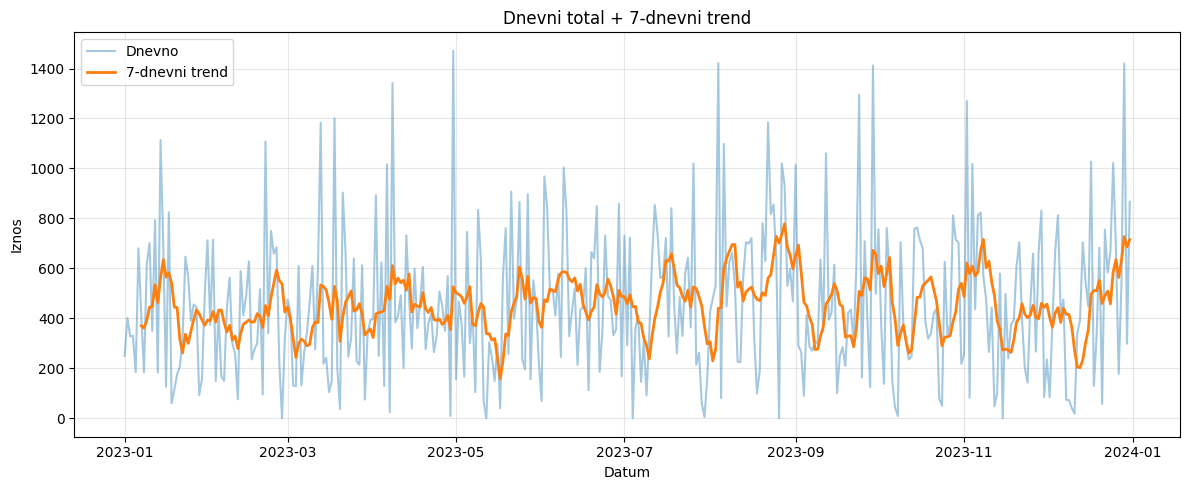

In [4]:
import matplotlib.pyplot as plt

daily_tmp= daily.copy()
daily_tmp["trend_7"] = daily_tmp["Total_Transaction"].rolling(window=7).mean()

plt.figure(figsize=(12, 5))

plt.plot(daily_tmp["Date"], daily_tmp["Total_Transaction"],
         label="Dnevno", alpha=0.4)

plt.plot(daily_tmp["Date"], daily_tmp["trend_7"],
         label="7-dnevni trend", linewidth=2)

plt.title("Dnevni total + 7-dnevni trend")
plt.xlabel("Datum")
plt.ylabel("Iznos")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

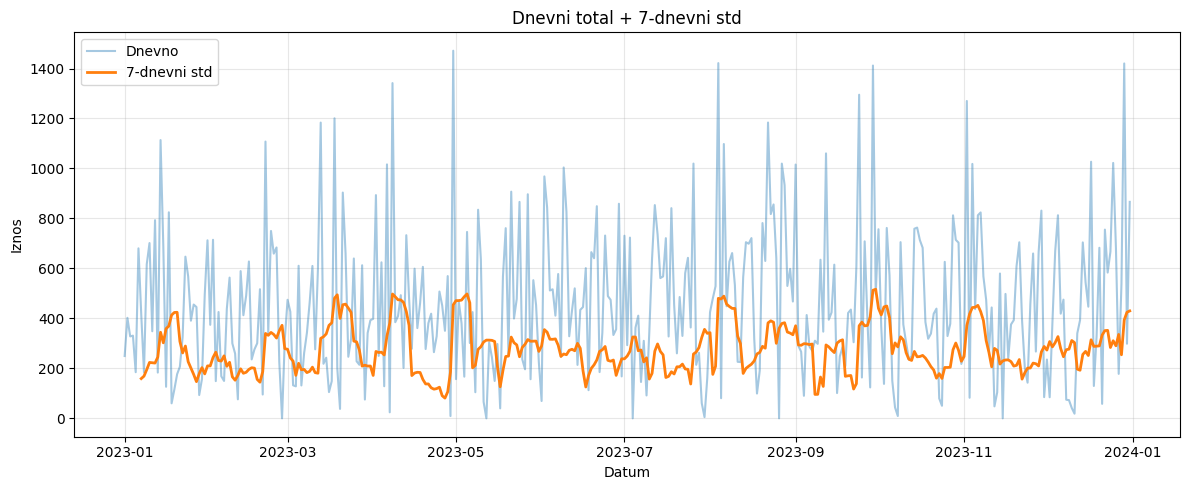

In [5]:
daily_tmp["rolling_std_7"] = daily_tmp["Total_Transaction"].rolling(7).std()

plt.figure(figsize=(12, 5))

plt.plot(daily_tmp["Date"], daily_tmp["Total_Transaction"],
         label="Dnevno", alpha=0.4)

plt.plot(daily_tmp["Date"], daily_tmp["rolling_std_7"],
         label="7-dnevni std", linewidth=2)

plt.title("Dnevni total + 7-dnevni std")
plt.xlabel("Datum")
plt.ylabel("Iznos")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

*Zaključak: signal pokazuje znakove nestacionarnosti - mean i std se mijenjaju kroz vrijeme, ALI! samo na osnovu vizualne inspekcije ne možemo dati konačnu tvrdnju, potrebni dodatni testovi*

### Autokorelacija: ACF/PACF
* **ACF (Autocorrelation Function):** mjeri ukupnu povezanost između vrijednosti niza i njegovih pomaka (lagova), pokazuje koliko prošle vrijednosti utječu na sadašnju; pomaže u odabiru **MA (q)** za ARIMA

* **PACF (Partial Autocorrelation):** mjeri izravnu povezanost između niza i određenog laga, uz uklanjanje utjecaja ostalih lagovi pokazuje koji lagovi imaju stvarni (direktni) utjecaj; pomaže u odabiru **AR (p)** za ARIMA

analiza na:
- 1.) izvornom signalu
- 2.) diff

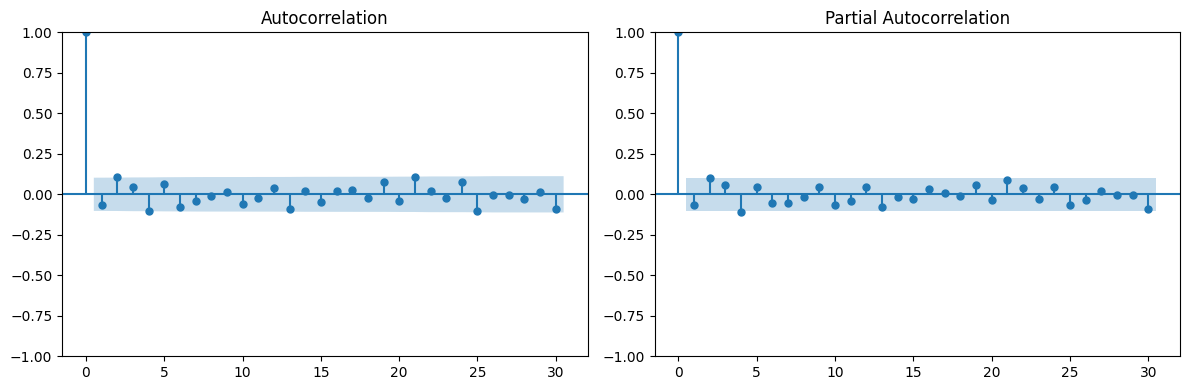

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,4))

plot_acf(daily["Total_Transaction"], ax=axes[0], lags=30)
plot_pacf(daily["Total_Transaction"], ax=axes[1], lags=30)

plt.tight_layout()
plt.show()

*nema izražene autokorelacije, slaba vremenska ovisnost*

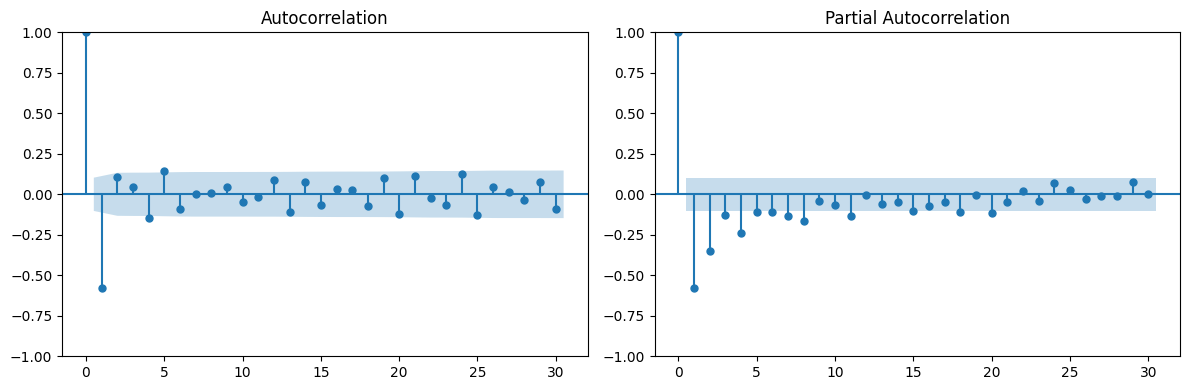

In [8]:
y_diff = daily["Total_Transaction"].diff().dropna()
fig, axes = plt.subplots(1, 2, figsize=(12,4))

plot_acf(y_diff, ax=axes[0], lags=30)
plot_pacf(y_diff, ax=axes[1], lags=30)

plt.tight_layout()
plt.show()

*jaka povezanost na lagu 1 → kratkoročna ovisnost*

### Stacionarnost (formalni testovi):
* **ADF** - testira postoji li trend, mala p-vrijednost ⇒ niz je **vjerojatno stacionaran**
* **KPSS** - testira je li niz stacionaran → mala p-vrijednost ⇒ niz je **nestacionaran**

In [9]:
from statsmodels.tsa.stattools import adfuller, kpss

adf_stat, adf_p, *_ = adfuller(daily["Total_Transaction"])
print("ADF p-value:", adf_p)

kpss_stat, kpss_p, *_ = kpss(daily["Total_Transaction"], regression='c')
print("KPSS p-value:", kpss_p)

ADF p-value: 1.5288229442685808e-16
KPSS p-value: 0.1


C:\Users\Nikolina\AppData\Local\Temp\ipykernel_27788\3645667434.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(daily["Total_Transaction"], regression='c')


*niz je čini se ipak vjerojatno stacionaran*

# 3. Predikcija
- **5-fold CV (vremenski!)** https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html
- Modeli:
    - jednostavno eksponencijalno zaglađivanje
    - ARIMA
    - PROPHET
    - XGBoost regresor

In [10]:
from sklearn.model_selection import TimeSeriesSplit
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error


tscv = TimeSeriesSplit(n_splits=5)

def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred))
    }

## 3.1. Jednostavno eksponencijalno zaglađivanje

- s obzirom da testovi nisu pokazali jasan trend, postavit ćemo ```trend=None```
- iako se ne vidi jaka sezonalnost, ipak ćemo pretpostaviti da ppstoji neki utjecaj tjedna

          MAE        RMSE  Fold
0  227.183991  323.614552     1
1  236.315073  279.919968     2
2  267.581569  334.075911     3
3  243.505392  295.130864     4
4  253.361558  317.329209     5

Average:
MAE     245.589517
RMSE    310.014101
Fold      3.000000
dtype: float64


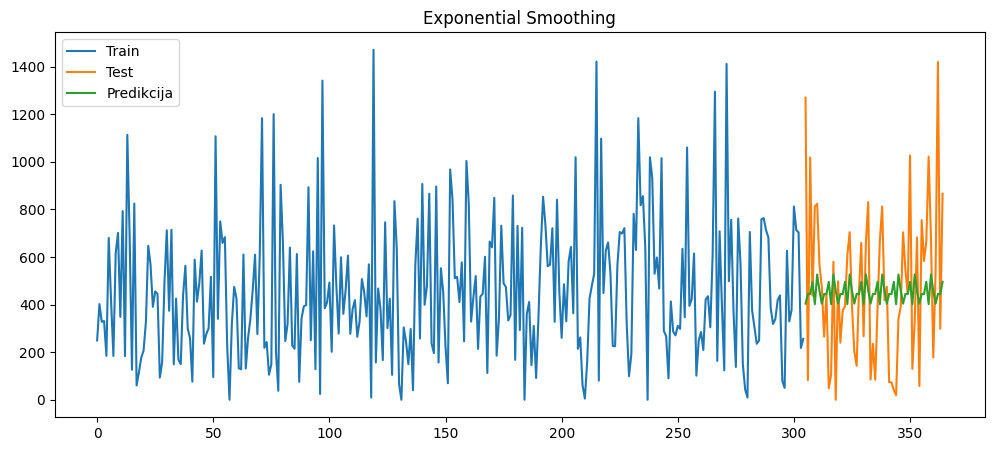

In [11]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

results = []

y = daily["Total_Transaction"]

for fold, (train_idx, test_idx) in enumerate(tscv.split(y), 1):

    train = y.iloc[train_idx]
    test = y.iloc[test_idx]

# ako se pozove samo fit(), model procjenjuje parametre automatski
    model = ExponentialSmoothing(train, trend=None, seasonal="add", seasonal_periods=7).fit()

# ako želimo, možemo i ručno podesiti
    '''
    model = ExponentialSmoothing(
        train,
        trend="add",
        seasonal="add",
        seasonal_periods=7
    ).fit(
        smoothing_level=0.8,   # alpha
        smoothing_trend=0.1,   # beta
        smoothing_seasonal=0.1,
        optimized=False
    )
    '''
    pred = model.forecast(len(test))

    scores = evaluate(test, pred)
    scores["Fold"] = fold
    results.append(scores)



results_df = pd.DataFrame(results)

print(results_df)
print("\nAverage:")
print(results_df.mean())


# zadnji fold
train = y.iloc[train_idx]
test = y.iloc[test_idx]

plt.figure(figsize=(12,5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, pred, label="Predikcija")

plt.legend()
plt.title("Exponential Smoothing")
plt.show()

## 3.2. ARIMA

- d = 0, jer je niz (slabo) stacionaran pa nema potrebe za diferenciranjem
- p = 0 ili 1, PACF nema jasan cutoff, vrlo slab AR dio
- q = 0 ili 1, ACF nema jasan cutoff, vrlo slab MA dio

           MAE        RMSE           Model  Fold
0   226.753777  317.926226  ARIMA(1, 0, 0)     1
1   223.500717  270.467421  ARIMA(1, 0, 0)     2
2   256.707161  321.393355  ARIMA(1, 0, 0)     3
3   228.337501  286.469569  ARIMA(1, 0, 0)     4
4   255.419712  319.521334  ARIMA(1, 0, 0)     5
5   226.734171  317.849349  ARIMA(0, 0, 1)     1
6   223.595962  270.646655  ARIMA(0, 0, 1)     2
7   256.740490  321.205163  ARIMA(0, 0, 1)     3
8   228.259647  286.422556  ARIMA(0, 0, 1)     4
9   255.468184  319.603245  ARIMA(0, 0, 1)     5
10  226.726201  317.957321  ARIMA(1, 0, 1)     1
11  223.502595  270.481503  ARIMA(1, 0, 1)     2
12  256.843258  321.521332  ARIMA(1, 0, 1)     3
13  228.525700  286.437882  ARIMA(1, 0, 1)     4
14  255.447572  319.688570  ARIMA(1, 0, 1)     5

Average:
                       MAE        RMSE
Model                                 
ARIMA(0, 0, 1)  238.159691  303.145394
ARIMA(1, 0, 0)  238.143773  303.155581
ARIMA(1, 0, 1)  238.209065  303.217322


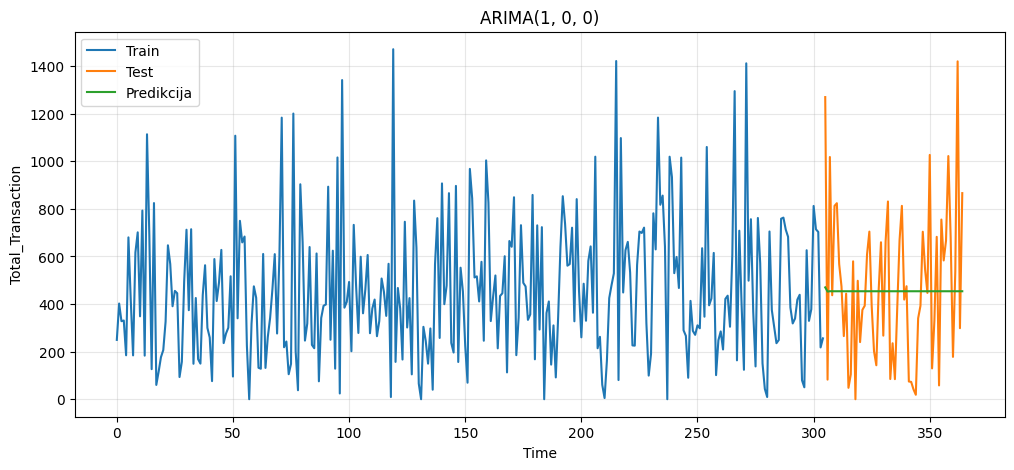

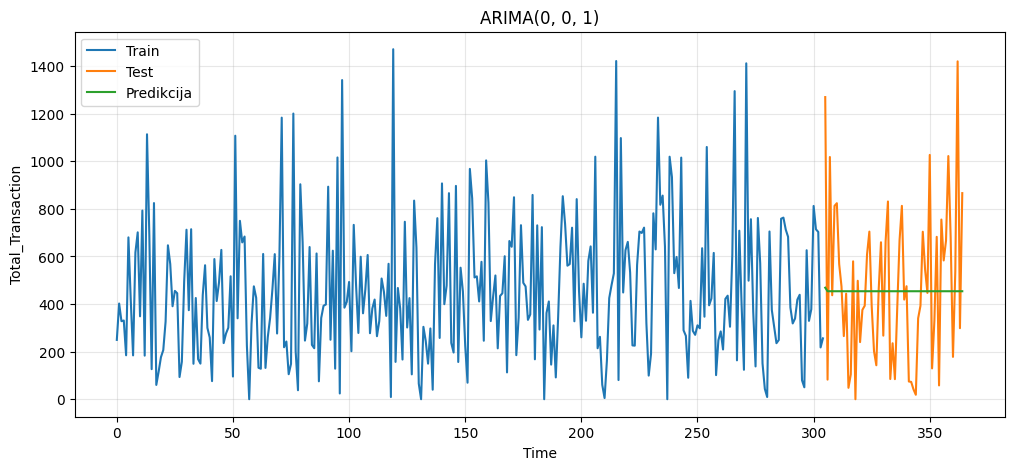

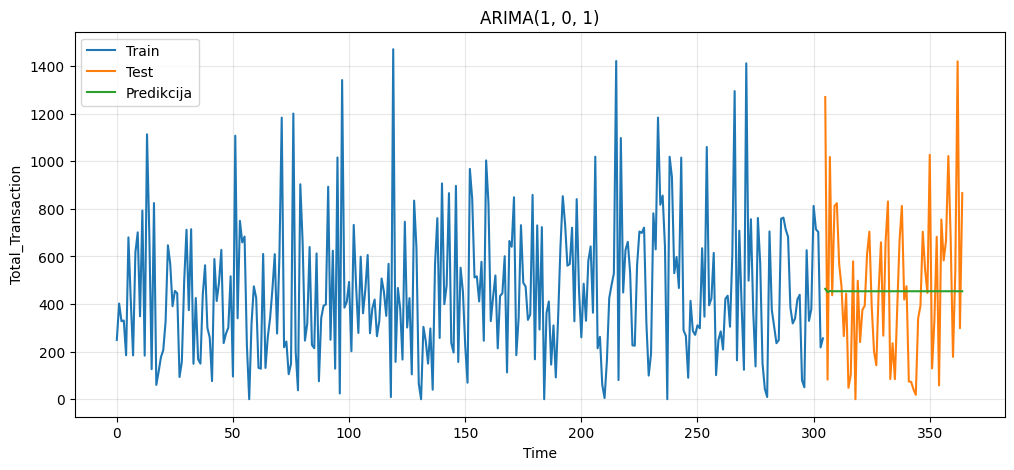

In [12]:
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

orders = [(1, 0, 0), (0, 0, 1), (1, 0, 1)]

all_results = []
predictions = {}

y = daily["Total_Transaction"]

for order in orders:
    fold_predictions = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(y), 1):

        train = y.iloc[train_idx]
        test = y.iloc[test_idx]

        model = ARIMA(train, order=order).fit()
        pred = model.forecast(len(test))

        scores = evaluate(test, pred)
        scores["Model"] = f"ARIMA{order}"
        scores["Fold"] = fold
        all_results.append(scores)

        fold_predictions.append({
            "fold": fold,
            "train": train,
            "test": test,
            "pred": pred
        })

    predictions[order] = fold_predictions


results_df = pd.DataFrame(all_results)

print(results_df)

print("\nAverage:")
print(
    results_df
    .groupby("Model")[["MAE", "RMSE"]]
    .mean()
    .sort_values("RMSE")
)


best_model_name = (
    results_df
    .groupby("Model")["RMSE"]
    .mean()
    .idxmin()
)


for order in orders:

    last_fold = predictions[order][-1]

    train = last_fold["train"]
    test = last_fold["test"]
    pred = last_fold["pred"]

    plt.figure(figsize=(12, 5))
    plt.plot(train.index, train, label="Train")
    plt.plot(test.index, test, label="Test")
    plt.plot(test.index, pred, label="Predikcija")

    plt.legend()
    plt.title(f"ARIMA{order}")
    plt.xlabel("Time")
    plt.ylabel("Total_Transaction")
    plt.grid(alpha=0.3)
    plt.show()

## 3.3 SARIMA
probat ćemo dodati i sezonalnost (7 dana kao u ES)

In [13]:
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

sarima_configs = [
    ((1, 0, 0), (1, 0, 0, 30)),
    ((0, 0, 1), (0, 0, 1, 30)),
    ((1, 0, 1), (1, 0, 1, 30)),
    ((1, 0, 1), (1, 1, 1, 30)),
]

all_results = []
predictions = {}

y = daily["Total_Transaction"]

for order, seasonal_order in sarima_configs:
    fold_predictions = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(y), 1):

        train = y.iloc[train_idx]
        test = y.iloc[test_idx]

        model = ARIMA(
            train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit()

        pred = model.forecast(steps=len(test))

        scores = evaluate(test, pred)
        scores["Model"] = f"SARIMA{order}x{seasonal_order}"
        scores["Fold"] = fold
        all_results.append(scores)

        fold_predictions.append({
            "fold": fold,
            "train": train,
            "test": test,
            "pred": pred
        })

    predictions[(order, seasonal_order)] = fold_predictions


results_df = pd.DataFrame(all_results)

print(results_df)

print("\nAverage:")
print(
    results_df
    .groupby("Model")[["MAE", "RMSE"]]
    .mean()
    .sort_values("RMSE")
)

           MAE        RMSE                          Model  Fold
0   225.440926  319.090084  SARIMA(1, 0, 0)x(1, 0, 0, 30)     1
1   221.810182  267.971890  SARIMA(1, 0, 0)x(1, 0, 0, 30)     2
2   254.331461  319.321107  SARIMA(1, 0, 0)x(1, 0, 0, 30)     3
3   235.091564  298.330286  SARIMA(1, 0, 0)x(1, 0, 0, 30)     4
4   257.482656  317.918147  SARIMA(1, 0, 0)x(1, 0, 0, 30)     5
5   229.184869  323.051584  SARIMA(0, 0, 1)x(0, 0, 1, 30)     1
6   221.513790  267.566801  SARIMA(0, 0, 1)x(0, 0, 1, 30)     2
7   253.103101  318.465293  SARIMA(0, 0, 1)x(0, 0, 1, 30)     3
8   234.254304  297.785399  SARIMA(0, 0, 1)x(0, 0, 1, 30)     4
9   258.122467  317.918483  SARIMA(0, 0, 1)x(0, 0, 1, 30)     5
10  230.501229  324.250005  SARIMA(1, 0, 1)x(1, 0, 1, 30)     1
11  223.096479  268.314732  SARIMA(1, 0, 1)x(1, 0, 1, 30)     2
12  253.483156  319.216593  SARIMA(1, 0, 1)x(1, 0, 1, 30)     3
13  234.399506  297.316756  SARIMA(1, 0, 1)x(1, 0, 1, 30)     4
14  258.062074  317.946126  SARIMA(1, 0,

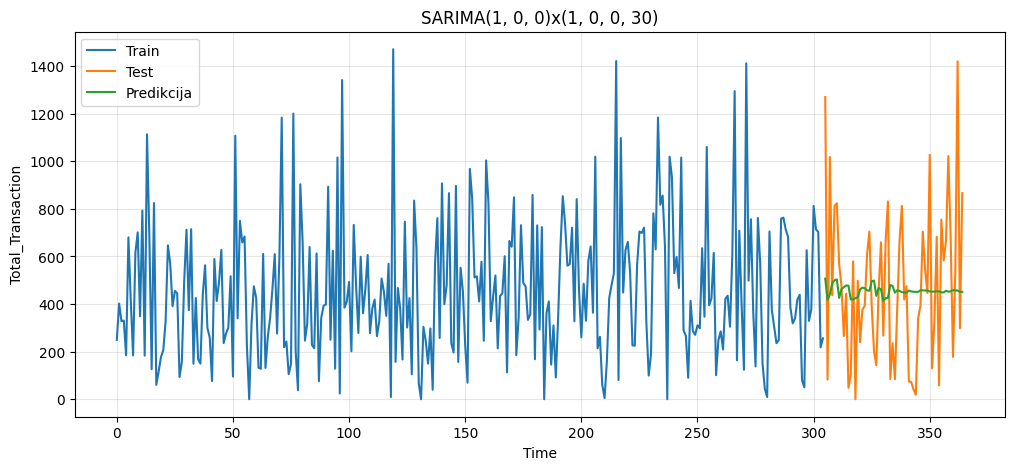

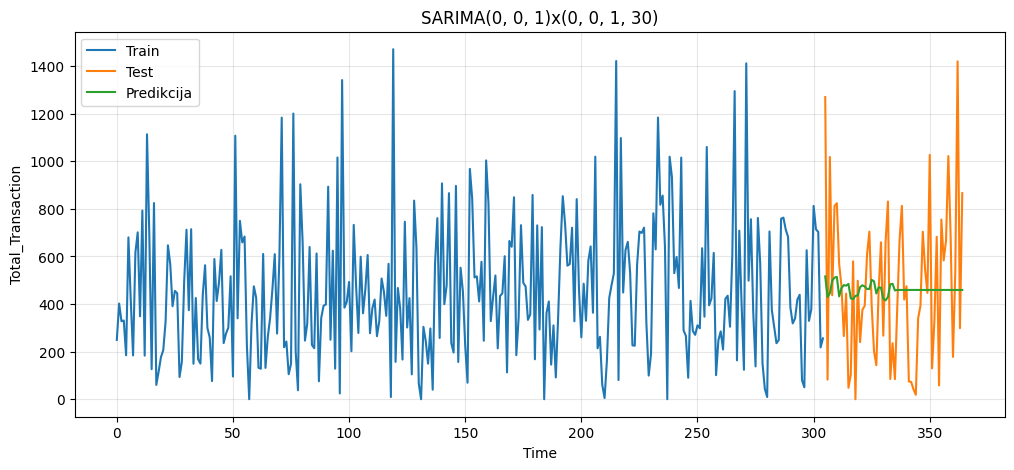

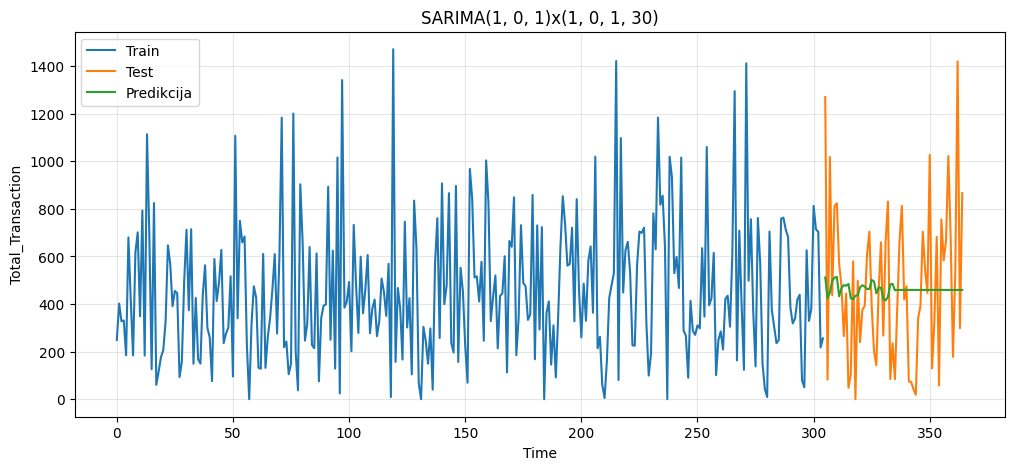

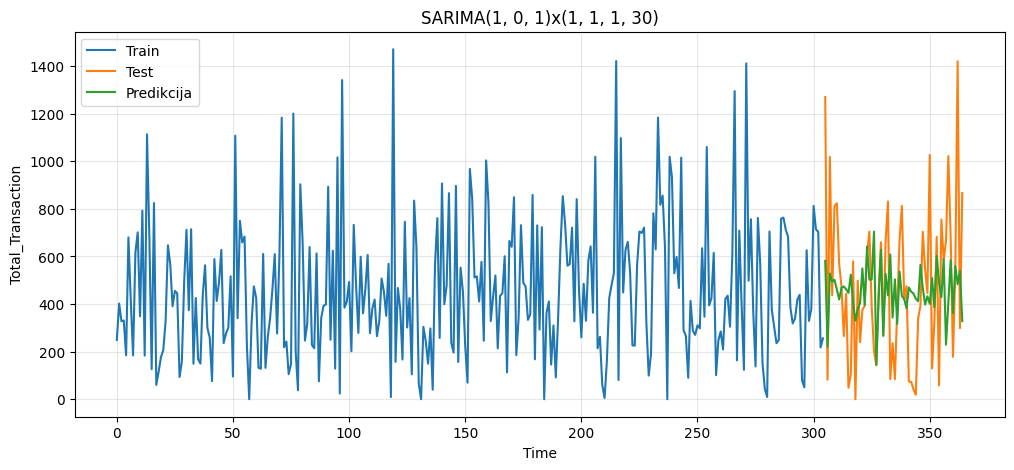

In [14]:
for config in sarima_configs:
    order, seasonal_order = config
    last_fold = predictions[config][-1]

    train = last_fold["train"]
    test = last_fold["test"]
    pred = last_fold["pred"]

    plt.figure(figsize=(12, 5))
    plt.plot(train.index, train, label="Train")
    plt.plot(test.index, test, label="Test")
    plt.plot(test.index, pred, label="Predikcija")

    plt.legend()
    plt.title(f"SARIMA{order}x{seasonal_order}")
    plt.xlabel("Time")
    plt.ylabel("Total_Transaction")
    plt.grid(alpha=0.3)
    plt.show()

*Zadnji model izgleda prirodnije, ali zapravo ne hvata dobro obrasce. ARIMA je linearni model, a očito postoje nelinearne reakcije pa je "najbolji" pogodak srednja vrijednost.*

## 3.3. PROPHET


Importing plotly failed. Interactive plots will not work.
17:26:16 - cmdstanpy - INFO - Chain [1] start processing
17:26:16 - cmdstanpy - INFO - Chain [1] done processing
17:26:16 - cmdstanpy - INFO - Chain [1] start processing
17:26:16 - cmdstanpy - INFO - Chain [1] done processing
17:26:16 - cmdstanpy - INFO - Chain [1] start processing
17:26:16 - cmdstanpy - INFO - Chain [1] done processing
17:26:16 - cmdstanpy - INFO - Chain [1] start processing
17:26:16 - cmdstanpy - INFO - Chain [1] done processing
17:26:16 - cmdstanpy - INFO - Chain [1] start processing
17:26:16 - cmdstanpy - INFO - Chain [1] done processing


          MAE        RMSE  Fold
0  228.533458  332.135452     1
1  239.671144  279.246426     2
2  257.203927  322.791509     3
3  258.396338  309.485495     4
4  255.512273  317.467436     5

Average:
MAE     247.863428
RMSE    312.225263
Fold      3.000000
dtype: float64


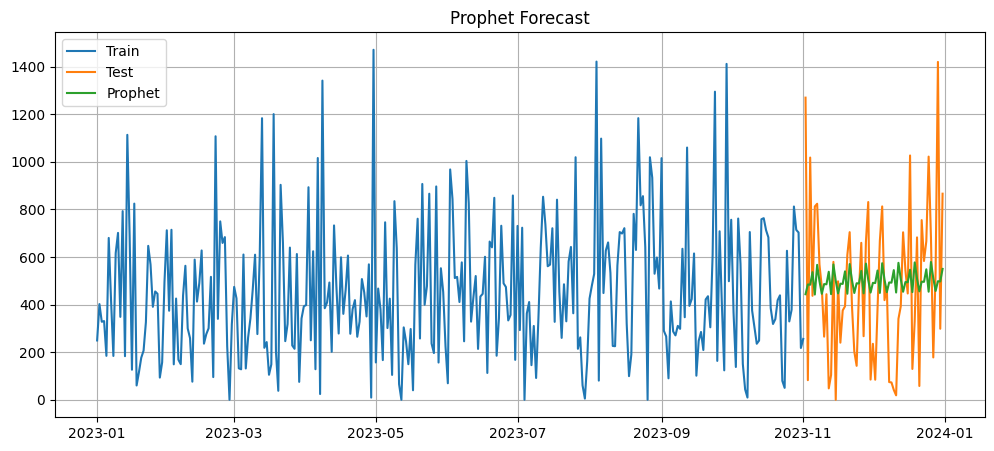

In [15]:
# naming konvencija

prophet_df = daily.rename(columns={
    "Date": "ds",
    "Total_Transaction": "y"
})

from prophet import Prophet

results = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(prophet_df), 1):

    train = prophet_df.iloc[train_idx]
    test = prophet_df.iloc[test_idx]

    model = Prophet(
        weekly_seasonality=True,
        daily_seasonality=False,
        yearly_seasonality=False,
        changepoint_prior_scale=0.1
    )

    model.fit(train)

    future = test[["ds"]]
    forecast = model.predict(future)

    pred = forecast["yhat"].values

    scores = evaluate(test["y"], pred)
    scores["Fold"] = fold
    results.append(scores)

results_df = pd.DataFrame(results)
print(results_df)
print("\nAverage:")
print(results_df.mean())



plt.figure(figsize=(12,5))

plt.plot(train["ds"], train["y"], label="Train")
plt.plot(test["ds"], test["y"], label="Test")
plt.plot(test["ds"], pred, label="Prophet")

plt.legend()
plt.title("Prophet Forecast")
plt.grid(True)
plt.show()

19:26:33 - cmdstanpy - INFO - Chain [1] start processing
19:26:33 - cmdstanpy - INFO - Chain [1] done processing
19:26:33 - cmdstanpy - INFO - Chain [1] start processing
19:26:33 - cmdstanpy - INFO - Chain [1] done processing
19:26:34 - cmdstanpy - INFO - Chain [1] start processing
19:26:34 - cmdstanpy - INFO - Chain [1] done processing
19:26:34 - cmdstanpy - INFO - Chain [1] start processing
19:26:34 - cmdstanpy - INFO - Chain [1] done processing
19:26:34 - cmdstanpy - INFO - Chain [1] start processing
19:26:34 - cmdstanpy - INFO - Chain [1] done processing


          MAE        RMSE  Fold
0  229.119881  331.446580     1
1  241.842484  281.461238     2
2  257.094536  322.697453     3
3  258.452486  309.566022     4
4  255.515766  317.472303     5

Average:
MAE     248.405031
RMSE    312.528719
Fold      3.000000
dtype: float64


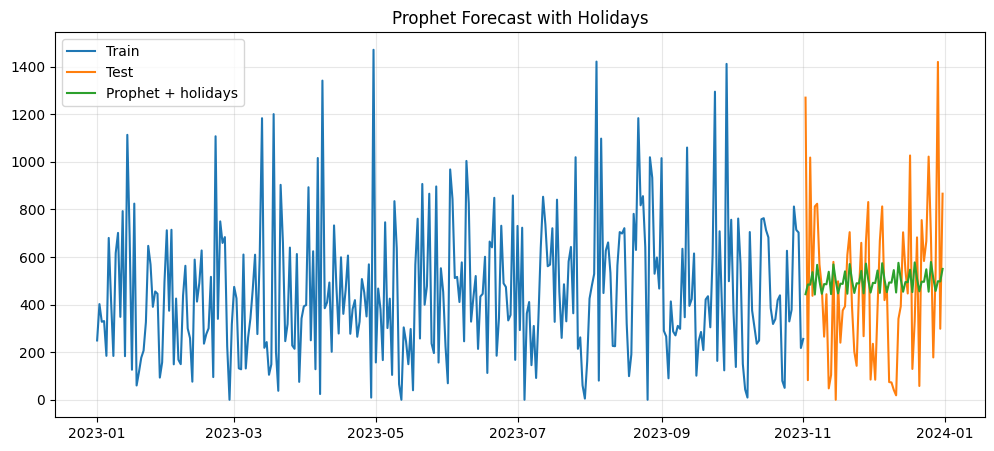

In [150]:
holidays = pd.DataFrame({
    "holiday": [
        "black_friday",
        "cyber_monday",
        "diwali",
        "singles_day",
        "thanksgiving",
        "boxing_day",
        "valentines_day"
    ],
    "ds": pd.to_datetime([
        "2023-11-24",  # Black Friday
        "2023-11-27",  # Cyber Monday
        "2023-11-12",  # Diwali
        "2023-11-11",  # Singles' Day
        "2023-11-23",  # Thanksgiving
        "2023-12-26",  # Boxing Day
        "2023-02-14",  # Valentine's Day
    ]),
    "lower_window": 0,
    "upper_window": 0
})

from prophet import Prophet

results = []
predictions = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(prophet_df), 1):

    train = prophet_df.iloc[train_idx]
    test = prophet_df.iloc[test_idx]

    model = Prophet(
        weekly_seasonality=True,
        daily_seasonality=False,
        yearly_seasonality=False,
        changepoint_prior_scale=0.1,
        holidays=holidays
    )

    model.fit(train)

    future = test[["ds"]]
    forecast = model.predict(future)

    pred = forecast["yhat"].values

    scores = evaluate(test["y"], pred)
    scores["Fold"] = fold
    results.append(scores)

    predictions.append({
        "fold": fold,
        "train": train,
        "test": test,
        "pred": pred,
        "forecast": forecast
    })

results_df = pd.DataFrame(results)

print(results_df)
print("\nAverage:")
print(results_df.mean(numeric_only=True))


last = predictions[-1]

train = last["train"]
test = last["test"]
pred = last["pred"]

plt.figure(figsize=(12, 5))

plt.plot(train["ds"], train["y"], label="Train")
plt.plot(test["ds"], test["y"], label="Test")
plt.plot(test["ds"], pred, label="Prophet + holidays")

plt.legend()
plt.title("Prophet Forecast with Holidays")
plt.grid(alpha=0.3)
plt.show()

## 3.4 XGBoost regresor
 - potrebno je dodavanje značajki u novi dataset
    - transformacija datuma
    - vremenski prozor (lag)

          MAE        RMSE  Fold
0  259.318921  343.126153     1
1  251.612458  314.297471     2
2  284.396735  354.545823     3
3  251.942072  315.024871     4
4  213.388152  270.703631     5


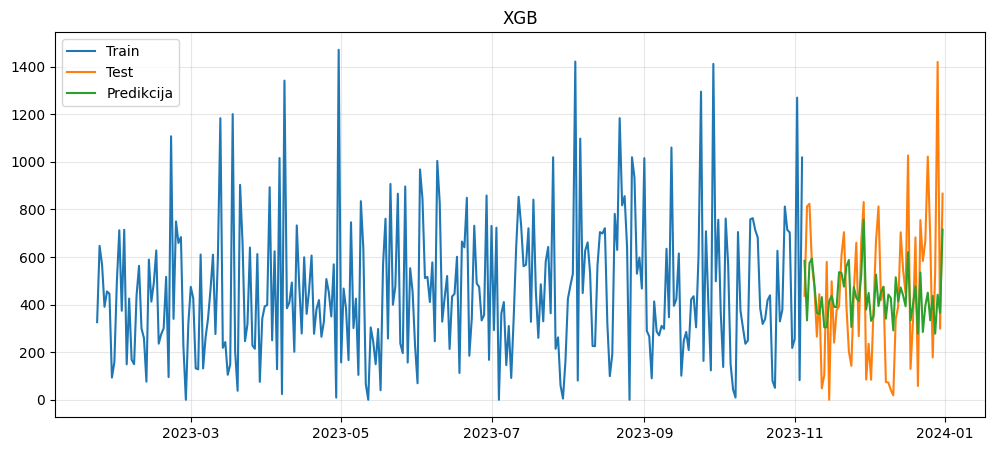

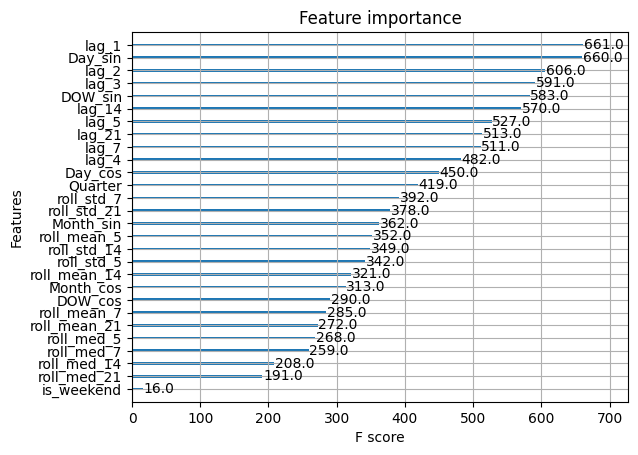

In [149]:
from xgboost import XGBRegressor, plot_importance


xgb_df = daily.copy()

xgb_df["Day"] = xgb_df["Date"].dt.day
xgb_df["Month"] = xgb_df["Date"].dt.month
xgb_df["Day_of_Week"] = xgb_df["Date"].dt.dayofweek
xgb_df["Quarter"] = xgb_df["Date"].dt.quarter


#cyclic
xgb_df["Month_sin"] = np.sin(2 * np.pi * xgb_df["Month"] / 12)
xgb_df["Month_cos"] = np.cos(2 * np.pi * xgb_df["Month"] / 12)
xgb_df["DOW_sin"] = np.sin(2 * np.pi * xgb_df["Day_of_Week"] / 7)
xgb_df["DOW_cos"] = np.cos(2 * np.pi * xgb_df["Day_of_Week"] / 7)
xgb_df["Day_sin"] = np.sin(2 * np.pi * xgb_df["Day"] / 31)
xgb_df["Day_cos"] = np.cos(2 * np.pi * xgb_df["Day"] / 31)

xgb_df["is_weekend"] = (xgb_df["Day_of_Week"] >= 5).astype(int)
xgb_df.drop(columns=["Day_of_Week", "Day", "Month"], inplace=True)

xgb_df["lag_1"] = xgb_df["Total_Transaction"].shift(1)
xgb_df["lag_2"] = xgb_df["Total_Transaction"].shift(2)
xgb_df["lag_3"] = xgb_df["Total_Transaction"].shift(3)
xgb_df["lag_4"] = xgb_df["Total_Transaction"].shift(4)
xgb_df["lag_5"] = xgb_df["Total_Transaction"].shift(5)
xgb_df["lag_7"] = xgb_df["Total_Transaction"].shift(7)
xgb_df["lag_14"] = xgb_df["Total_Transaction"].shift(14)
xgb_df["lag_21"] = xgb_df["Total_Transaction"].shift(21)
#xgb_df["lag_30"] = xgb_df["Total_Transaction"].shift(30)


xgb_df["roll_mean_5"] = xgb_df["Total_Transaction"].shift(1).rolling(5).mean()
xgb_df["roll_std_5"] = xgb_df["Total_Transaction"].shift(1).rolling(5).std()
xgb_df["roll_med_5"] = xgb_df["Total_Transaction"].shift(1).rolling(5).median()



xgb_df["roll_mean_7"] = xgb_df["Total_Transaction"].shift(1).rolling(7).mean()
xgb_df["roll_std_7"] = xgb_df["Total_Transaction"].shift(1).rolling(7).std()
xgb_df["roll_med_7"] = xgb_df["Total_Transaction"].shift(1).rolling(7).median()

xgb_df["roll_mean_14"] = xgb_df["Total_Transaction"].shift(1).rolling(14).mean()
xgb_df["roll_std_14"] = xgb_df["Total_Transaction"].shift(1).rolling(14).std()
xgb_df["roll_med_14"] = xgb_df["Total_Transaction"].shift(1).rolling(14).median()

xgb_df["roll_mean_21"] = xgb_df["Total_Transaction"].shift(1).rolling(21).mean()
xgb_df["roll_std_21"] = xgb_df["Total_Transaction"].shift(1).rolling(21).std()
xgb_df["roll_med_21"] = xgb_df["Total_Transaction"].shift(1).rolling(21).median()

'''# learn spikes
threshold = y_train.mean() + 1.5 * y_train.std()
xgb_df["is_spike"] = (xgb_df["Total_Transaction"] > threshold).astype(int)
spike_days = xgb_df.loc[xgb_df["is_spike"] == 1, "Date"]

def days_to_nearest_spike(date):
    return min((abs((date - d).days) for d in spike_days), default=999)

xgb_df["days_to_spike"] = xgb_df["Date"].apply(days_to_nearest_spike)
'''



'''

holidays = pd.to_datetime([
    "2023-02-14",  # Valentine's Day
    "2023-04-09",  #Easter
    "2023-05-14", #Mothers day
    "2023-10-31", #Halloween
    "2023-11-24",  # Black Friday
    "2023-11-27",  # Cyber Monday
    "2023-12-25",  # Christmas
    "2023-12-26",  # Boxing day
    "2023-01-01",  # New Year
])

xgb_df["holiday_soon"] = [
    int(any(0 <= (h - d).days <= 5 for h in holidays))
    for d in xgb_df["Date"]
]
'''


# drop missing rows due to lagging (if any)
xgb_df = xgb_df.dropna()


X = xgb_df.drop(columns=["Date", "Total_Transaction"])
y = xgb_df["Total_Transaction"]

results = []
predictions = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]


    model = XGBRegressor(
        n_estimators=300,
        max_depth=7,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,            # L1
        reg_lambda=1.0,     #L2
        objective="reg:squarederror",
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)


    scores = evaluate(y_test, pred)
    scores["Fold"] = fold
    results.append(scores)

    predictions.append({
        "fold": fold,
        "train_idx": train_idx,
        "test_idx": test_idx,
        "pred": pred
    })

results_df = pd.DataFrame(results)
print(results_df)


last = predictions[-1]

train_idx = last["train_idx"]
test_idx = last["test_idx"]
pred = last["pred"]

train = xgb_df.iloc[train_idx]
test = xgb_df.iloc[test_idx]

plt.figure(figsize=(12,5))
plt.plot(train["Date"], train["Total_Transaction"], label="Train")
plt.plot(test["Date"], test["Total_Transaction"], label="Test")
plt.plot(test["Date"], pred, label="Predikcija")

plt.legend()
plt.title("XGB")
plt.grid(alpha=0.3)
plt.show()

plot_importance(model)
plt.show()

*Kraj godine je malo specifično razdoblje pa je realno za očekivati da tu nijedan model koji "nije vidio" prosinac ranije neće dobro raditi.*